<a href="https://colab.research.google.com/github/Elwing-Chou/ximen_ai_20260706/blob/main/ximen20260803.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

深度學習:

1. tesorflow(Google): 我是打算使用tf裡的keras, 比較方便
2. pytorch(meta):

In [54]:
from tensorflow.keras.datasets.fashion_mnist import load_data
# ((x_train, y_train), (x_Test, y_test))
(x_train, y_train), (x_test, y_test) = load_data()

In [55]:
tags = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

Ankle boot


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,...,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,...,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,...,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,...,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,...,235,227,224,222,224,221,223,245,173,0


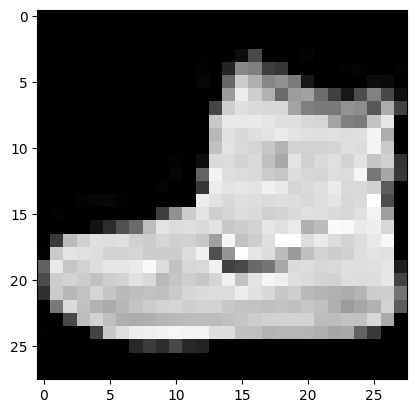

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
# 0: black 255: white
print(tags[y_train[0]])
plt.imshow(x_train[0], cmap="gray")
pd.DataFrame(x_train[0])

In [57]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [58]:
import numpy as np
demo = np.array([
    [2, 3],
    [1, 4],
    [5, 6]
])
demo.reshape(2, 3)
# -1: 叫他幫你算
demo.reshape(2, -1)

array([[2, 3, 1],
       [4, 5, 6]])

In [59]:
# 因為你的w的隨機是在某個區間的
# 那理所當然你的x也應該要有個區間 -> w*x 才會是某個區間
# tensorflow, torch: 0-1 -1~1
x_train_reshape = x_train.reshape(60000, 784) / 255.0
x_test_reshape = x_test.reshape(10000, 784) / 255.0

In [60]:
# from sklearn.manifold import TSNE
# import seaborn as sns
# tsne = TSNE()
# x_tsne = tsne.fit_transform(x_test_reshape)
# axis1 = x_tsne[:, 0]
# axis2 = x_tsne[:, 1]

In [61]:
# sns.scatterplot(x=axis1, y=axis2, hue=y_test, palette="tab10")

In [62]:
# 你只要準備個地基(model), 在一層一層(layer)蓋上去就可以了
from tensorflow.keras.models import Sequential
# Dense: 全連結層
from tensorflow.keras.layers import Dense

layers = [
    # 784->128(可自由調整)->10
    Dense(128, activation="relu", input_dim=784),
    Dense(10, activation="sigmoid")
]
model = Sequential(layers)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras.losses import CategoricalCrossentropy
model.compile(loss=CategoricalCrossentropy(), metrics=["accuracy"])

In [64]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
y_train_cat[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

- 沒做任何調整前: 30次訓練 81.2%
- /255.0: 84次訓練 87.9% -> 把它調整到合理區間, 才可以真正往正確的地方走(如果不調, 你有可能距離正確答案10萬八千里, 就算你有進步, 我也覺得沒進步)
- MSE->Cross Entropy: 18次訓練 88.0% -> 訓練速度非比尋常的增加了(因為你在距離很遠的時候, 斜率變大了, 調整變快了)

- 以後只要中間層, 全部的激活函數都換成relu, 有效的減少梯度消失現象, 讓你前面幾層的參數調整得比較好: 9次訓練 87.9%

In [65]:
# validation_split: 切出一部分資料不給看, 看表現多好
# epochs: 每一題都看?遍
# batch_size: 看?題才做一次參數的調整(平均) 不太多也不太少(20-100)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
callbacks = [
    # ModelCheckpoint("model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

model.fit(x_train_reshape,
          y_train_cat,
          validation_split=0.2,
          batch_size=100,
          epochs=100,
          callbacks=callbacks)
# model.save("model.h5")

Epoch 1/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7948 - loss: 0.5864 - val_accuracy: 0.8443 - val_loss: 0.4391
Epoch 2/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8496 - loss: 0.4202 - val_accuracy: 0.8466 - val_loss: 0.4188
Epoch 3/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8651 - loss: 0.3718 - val_accuracy: 0.8646 - val_loss: 0.3792
Epoch 4/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8777 - loss: 0.3395 - val_accuracy: 0.8740 - val_loss: 0.3546
Epoch 5/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8832 - loss: 0.3214 - val_accuracy: 0.8798 - val_loss: 0.3384
Epoch 6/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8886 - loss: 0.3040 - val_accuracy: 0.8807 - val_loss: 0.3284
Epoch 7/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8930 - loss: 0.2906 - val_accuracy: 0.8803 - val_loss: 0.3387
Epoch 8/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8957 - loss: 0.2799 - val_accu

In [67]:
# model.predict(x_test_reshape).argmax(axis=1)
model.evaluate(x_test_reshape, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8793 - loss: 0.3401


[0.3400883972644806, 0.8792999982833862]